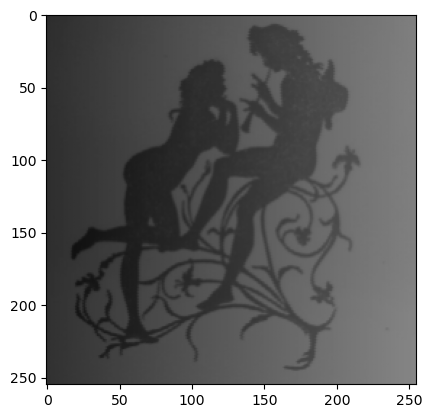

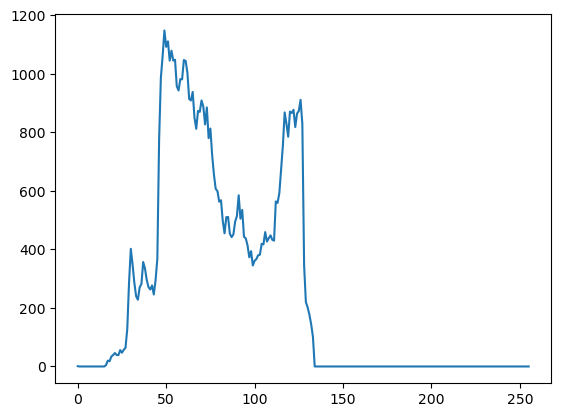

In [128]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

image = cv2.imread("images/AMOUR2.png", cv2.IMREAD_GRAYSCALE)

# Visualizar imagen
plt.imshow(image, cmap="gray",  vmin=0, vmax=255)
plt.show()

# Visualizar histograma
hist = cv2.calcHist([image],[0],None,[256],[0,256])
plt.plot(hist)
plt.show()



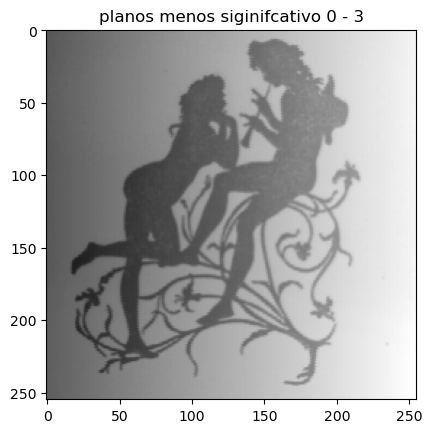

In [129]:
def bit_plane_slicing(imagen, k):
    plane = np.full((imagen.shape[0], imagen.shape[1]), 2 ** k, np.uint8)
    return cv2.bitwise_and(plane, imagen)

plane = bit_plane_slicing(image,0)
plane1 = bit_plane_slicing(image,1)
plane2 = bit_plane_slicing(image,2)
plane3 = bit_plane_slicing(image,3)
plane4 = bit_plane_slicing(image,4)
plane5 = bit_plane_slicing(image,5)
plane6 = bit_plane_slicing(image,6)
plane7 = bit_plane_slicing(image,7)

image_reconstructed = (plane+plane1+plane2+plane3+plane4+plane5+plane6+plane7)


final_image = (plane+plane1+plane2+plane3+plane4 + plane5 + plane6 +plane7)
plt.imshow(final_image, cmap="gray")
plt.title("planos menos siginifcativo 0 - 3")
plt.show()



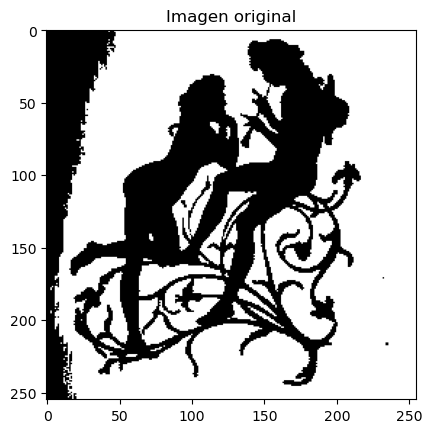

int64
0 255


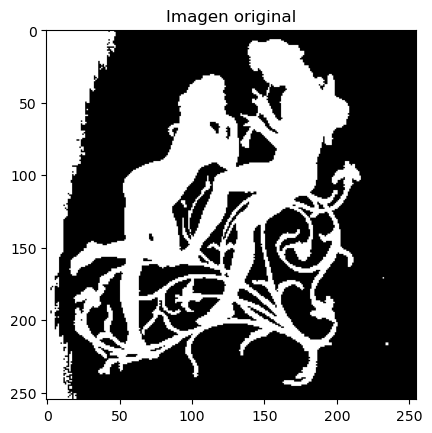

In [130]:
from skimage.filters import threshold_local

# ---- Imagen original ------
ti = threshold_local(final_image, block_size=123, method='mean')
binary_image = final_image > ti
thresholded_image = binary_image*255

# Visualizar imagen
plt.imshow(thresholded_image, cmap="gray",  vmin=0, vmax=255)
plt.title("Imagen original")
plt.show()
print(thresholded_image.dtype)
print(thresholded_image.min(), thresholded_image.max())

thresholded_image = thresholded_image.astype("uint8")
inverted = cv2.bitwise_not(thresholded_image)
plt.imshow(inverted, cmap="gray",  vmin=0, vmax=255)
plt.title("Imagen original")
plt.show()